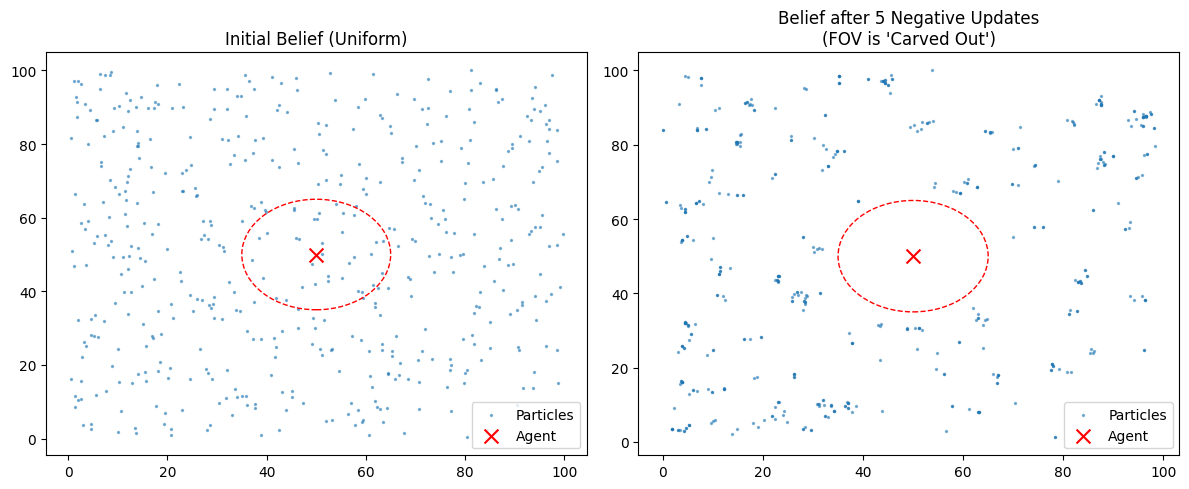

New Belief Mean: [42.65533198 50.88410098]
Notice: The mean has shifted away from [50. 50.] even without seeing the target!


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class ParticleFilter:
    def __init__(self, num_particles, area_size, sensor_range):
        self.num_particles = num_particles
        self.area_size = area_size
        self.sensor_range = sensor_range
        # Initialize particles randomly
        self.particles = np.random.uniform(0, area_size, (num_particles, 2))
        self.weights = np.ones(num_particles) / num_particles

    def predict(self, dt, std_pos):
        """ Constant velocity or random walk transition model """
        self.particles += np.random.normal(0, std_pos, self.particles.shape)
        # Boundary check
        self.particles = np.clip(self.particles, 0, self.area_size)

    def update(self, agent_pos, observed=False, target_pos=None):
        """
        The Bayesian Update:
        If observed: Standard likelihood based on distance.
        If NOT observed: Negative likelihood (1 - prob_of_detection).
        """
        distances = np.linalg.norm(self.particles - agent_pos, axis=1)
        
        # Simple sensor model: 90% detection probability if within range
        p_detection = 0.9
        
        if observed:
            # Standard Update: Weight particles based on proximity to actual target
            # (Assuming a Gaussian measurement noise)
            meas_noise = 2.0
            dist_to_target = np.linalg.norm(self.particles - target_pos, axis=1)
            self.weights *= np.exp(-dist_to_target**2 / (2 * meas_noise**2))
        else:
            # Negative Information Update: 
            # If a particle is in range, but we saw nothing, it's likely NOT there.
            in_range = distances < self.sensor_range
            
            # Likelihood of NOT seeing the target given it IS at particle location
            # L(z=null | x) = 1 - P(Detection | x)
            likelihood = np.ones(self.num_particles)
            likelihood[in_range] = (1 - p_detection)
            
            self.weights *= likelihood

        # Normalize weights
        self.weights += 1e-300  # avoid division by zero
        self.weights /= np.sum(self.weights)

    def resample(self):
        """ Systematic resampling to maintain diversity and shift the mean """
        indices = np.random.choice(
            np.arange(self.num_particles), 
            size=self.num_particles, 
            p=self.weights
        )
        self.particles = self.particles[indices]
        self.weights = np.ones(self.num_particles) / self.num_particles

    def get_belief(self):
        """ Returns the mean and entropy (proxy) """
        mean = np.mean(self.particles, axis=0)
        # Approximate entropy using variance
        cov = np.cov(self.particles.T)
        entropy = 0.5 * np.log(np.linalg.det(2 * np.pi * np.exp(1) * cov + 1e-6))
        return mean, entropy

# --- Simulation ---
np.random.seed(42)
pf = ParticleFilter(num_particles=500, area_size=100, sensor_range=15)
agent_pos = np.array([50.0, 50.0])
target_pos = np.array([55.0, 55.0]) # Target is near the center

# Visualize the 'Carving' effect
plt.figure(figsize=(12, 5))

# 1. Initial state (Agent hasn't looked yet)
plt.subplot(1, 2, 1)
plt.scatter(pf.particles[:,0], pf.particles[:,1], s=2, alpha=0.5, label='Particles')
plt.scatter(agent_pos[0], agent_pos[1], color='red', marker='x', s=100, label='Agent')
circle = plt.Circle(agent_pos, pf.sensor_range, color='r', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.title("Initial Belief (Uniform)")
plt.legend()

# 2. Update with "No Observation" and Resample
# We do this for 5 steps to show the 'clearing' of the FOV
for _ in range(5):
    pf.predict(dt=1, std_pos=0.5)
    pf.update(agent_pos, observed=False)
    pf.resample()

plt.subplot(1, 2, 2)
plt.scatter(pf.particles[:,0], pf.particles[:,1], s=2, alpha=0.5, label='Particles')
plt.scatter(agent_pos[0], agent_pos[1], color='red', marker='x', s=100, label='Agent')
circle = plt.Circle(agent_pos, pf.sensor_range, color='r', fill=False, linestyle='--')
plt.gca().add_artist(circle)
plt.title("Belief after 5 Negative Updates\n(FOV is 'Carved Out')")
plt.legend()

plt.tight_layout()
plt.show()

mean, entropy = pf.get_belief()
print(f"New Belief Mean: {mean}")
print(f"Notice: The mean has shifted away from {agent_pos} even without seeing the target!")